# Demo: class weights necessarie — U-Net 5 epoche, baseline vs pesata

Confronto controllato su un subset arricchito di classi rare: **stessi dati, stesso seed, stessa architettura — cambia solo la loss**.
Output: tabella per-classe (precision/recall/F1/IoU) e grafico di confronto, pronti per la sezione 6 del report.

Tempo stimato: pochi minuti su GPU, 30-90 min su CPU (riduci `N_RIDGE`/`N_CRATER`/`EPOCHS` se serve).

In [3]:
# CELLA 1 — setup (adatta i path se necessario)
import os, sys, random
import numpy as np, pandas as pd, torch
from pathlib import Path

sys.path.append(os.path.abspath('.'))   # come nel resto del notebook di test

from lunar_segmentation.models.unet import SmallUNet
from lunar_segmentation.data.datasets import MoonTileDataset
from lunar_segmentation.training.trainer import Trainer, BCEDiceLoss
from lunar_segmentation.data.preprocessing import CLASS_NAMES

TILE_DIR = Path('/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills')
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EPOCHS, BATCH_SIZE, SEED = 3, 8, 42
N_RIDGE, N_CRATER = 250, 150     # campioni di wrinkle_ridge e di tile solo-crateri nel subset

print('device:', DEVICE, '| tile dir ok:', TILE_DIR.exists())

device: cpu | tile dir ok: True


In [4]:
# CELLA 2 — scansione presenza classi per tile (una tantum, poi resta in cache su csv)
CACHE = Path('class_presence_cache.csv')

if CACHE.exists():
    pres = pd.read_csv(CACHE)
    print('cache trovata:', len(pres), 'tile')
else:
    tile_paths = sorted(TILE_DIR.glob('*.npz'))
    print(f'Scansione di {len(tile_paths)} tile (~3-5 min)...')
    rows = []
    for i, p in enumerate(tile_paths):
        m = np.load(p)['mask']
        rows.append({'tile_path': str(p),
                     'row': int(p.stem.split('_r')[1].split('_c')[0]),
                     **{name: int(m[c].sum() > 0) for c, name in enumerate(CLASS_NAMES)}})
        if (i + 1) % 2000 == 0:
            print(f'  {i+1} fatti')
    pres = pd.DataFrame(rows)
    pres.to_csv(CACHE, index=False)

print('\ntile contenenti ciascuna classe:')
print(pres[CLASS_NAMES].sum().to_string())

Scansione di 15909 tile (~3-5 min)...
  2000 fatti
  4000 fatti
  6000 fatti
  8000 fatti
  10000 fatti
  12000 fatti
  14000 fatti

tile contenenti ciascuna classe:
impact_crater           15909
pit_skylight              246
wrinkle_ridge            2987
lobate_scarp              271
irregular_mare_patch      103
apollo_site               175
candidate_rille            20


In [5]:
# CELLA 3 — subset arricchito di classi rare + split spaziale 80/20 sulla riga
rare = [c for c in CLASS_NAMES if c not in ('impact_crater', 'wrinkle_ridge')]

has_rare    = pres[pres[rare].sum(axis=1) > 0]                                        # tutti i tile con classi rare
has_ridge   = pres[(pres['wrinkle_ridge'] == 1) & (pres[rare].sum(axis=1) == 0)]
only_crater = pres[pres[CLASS_NAMES[1:]].sum(axis=1) == 0]

subset = pd.concat([
    has_rare,
    has_ridge.sample(min(N_RIDGE, len(has_ridge)), random_state=SEED),
    only_crater.sample(min(N_CRATER, len(only_crater)), random_state=SEED),
]).drop_duplicates('tile_path').reset_index(drop=True)

thr      = np.quantile(subset['row'], 0.8)          # split spaziale: niente leakage tra tile adiacenti
train_df = subset[subset['row'] <  thr].reset_index(drop=True)
val_df   = subset[subset['row'] >= thr].reset_index(drop=True)

print(f'{len(subset)} tile nel subset -> {len(train_df)} train / {len(val_df)} val')
print('\npresenza classi nel VAL (se una classe è a 0, la sua riga nelle metriche non è informativa):')
print(val_df[CLASS_NAMES].sum().to_string())

1172 tile nel subset -> 931 train / 241 val

presenza classi nel VAL (se una classe è a 0, la sua riga nelle metriche non è informativa):
impact_crater           241
pit_skylight             56
wrinkle_ridge            76
lobate_scarp             64
irregular_mare_patch      0
apollo_site              38
candidate_rille           0


In [6]:
# CELLA 4 — dataloader + loss pesata (identica alla cella già testata del notebook)
import torch.nn as nn
from torch.utils.data import DataLoader

train_ds = MoonTileDataset(train_df, augment=False)   # augment off su entrambi: confronto A/B pulito
val_ds   = MoonTileDataset(val_df,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class WeightedBCEDiceLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()ev/null | head
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00086_c00097.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00087_c00148.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00043_c00003.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00010_c00066.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00017_c00053.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00019_c00005.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00041_c00104.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00031_c00168.npz
/mnt/p4/MoonRec-MNTP/data/MR/data/data/processed/tiles/marius_hills/marius_hills_r00003_c00003.npz
/mnt/p4/MoonRec-MNTP/data/MR/data
        self.register_buffer('w', class_weights)
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.w.view(1, -1, 1, 1))
        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum(dim=(0, 2, 3))
        den = probs.sum(dim=(0, 2, 3)) + targets.sum(dim=(0, 2, 3))
        dice = (1 - (num + 1e-6) / (den + 1e-6)) * self.w
        return bce * 0.5 + dice.mean() * 0.5

CLASS_W = {'impact_crater': 1.0, 'pit_skylight': 64.7, 'wrinkle_ridge': 5.3,
           'lobate_scarp': 58.7, 'irregular_mare_patch': 154.4,
           'apollo_site': 90.9, 'candidate_rille': 795.0}          # = class_weights del .yaml
w = torch.tensor([CLASS_W[n] for n in CLASS_NAMES], dtype=torch.float32)
print('pesi:', dict(zip(CLASS_NAMES, w.tolist())))

pesi: {'impact_crater': 1.0, 'pit_skylight': 64.69999694824219, 'wrinkle_ridge': 5.300000190734863, 'lobate_scarp': 58.70000076293945, 'irregular_mare_patch': 154.39999389648438, 'apollo_site': 90.9000015258789, 'candidate_rille': 795.0}


In [7]:
# CELLA 5 — training A/B: stessa init (seed), stessi dati, cambia solo la loss
def run_training(criterion, tag):
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = SmallUNet(in_channels=3, num_classes=len(CLASS_NAMES))
    opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    tr    = Trainer(model, opt, criterion.to(DEVICE), device=DEVICE)
    for ep in range(EPOCHS):
        loss = tr.train_one_epoch(train_loader)
        print(f'  [{tag}] epoch {ep+1}/{EPOCHS}  train_loss = {loss:.4f}')
    metrics = tr.evaluate(val_loader)     # per-classe: precision/recall/f1/iou (soglia 0.5)
    torch.save(model.state_dict(), f'unet_demo_{tag}.pth')
    return metrics

print('--- baseline (loss NON pesata, come nel training ufficiale) ---')
m_base = run_training(BCEDiceLoss(), 'baseline')

print('\n--- weighted (stessa cosa, ma con le class weights) ---')
m_wgt = run_training(WeightedBCEDiceLoss(w), 'weighted')

--- baseline (loss NON pesata, come nel training ufficiale) ---
  [baseline] epoch 1/3  train_loss = 1.4352
  [baseline] epoch 2/3  train_loss = 1.2595
  [baseline] epoch 3/3  train_loss = 1.1299

--- weighted (stessa cosa, ma con le class weights) ---
  [weighted] epoch 1/3  train_loss = 83.7547
  [weighted] epoch 2/3  train_loss = 83.6556
  [weighted] epoch 3/3  train_loss = 83.5813


In [8]:
# CELLA 6 — confronto per classe
cmp = pd.concat({'unweighted': m_base, 'weighted': m_wgt}, axis=1).round(3)
print(cmp.to_string())
cmp.to_csv('demo_weighted_vs_baseline.csv')
print('\nsalvato: demo_weighted_vs_baseline.csv')

                     unweighted                       weighted                     
                      precision recall     f1    iou precision recall     f1    iou
class                                                                              
apollo_site               0.000    0.0  0.000  0.000     0.000  0.000  0.000  0.000
candidate_rille           0.000    0.0  0.000  0.000     0.000  0.000  0.000  0.000
impact_crater             0.963    1.0  0.981  0.963     0.963  1.000  0.981  0.963
irregular_mare_patch      0.000    0.0  0.000  0.000     0.000  0.000  0.000  0.000
lobate_scarp              0.000    0.0  0.000  0.000     0.000  0.000  0.000  0.000
pit_skylight              0.000    0.0  0.000  0.000     0.013  0.174  0.023  0.012
wrinkle_ridge             0.000    0.0  0.000  0.000     0.006  0.000  0.000  0.000

salvato: demo_weighted_vs_baseline.csv


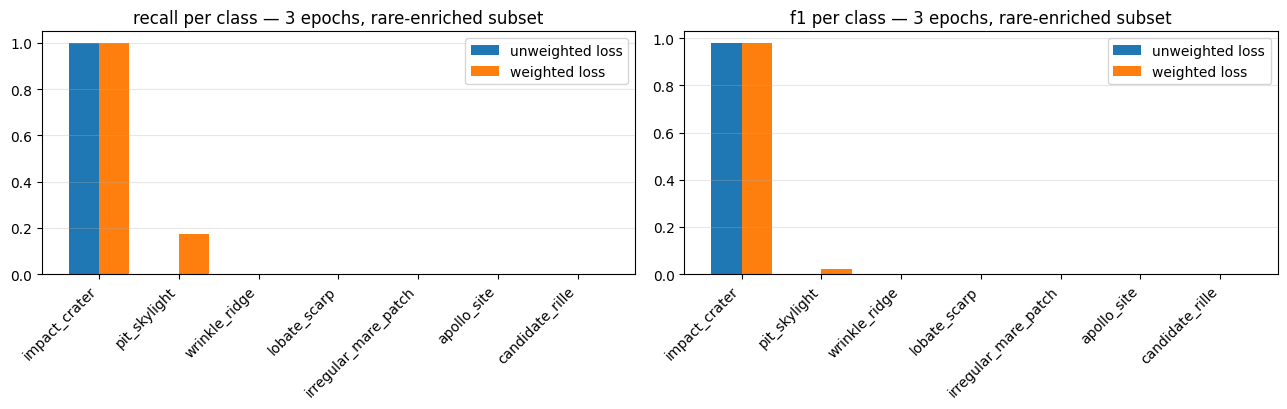

salvato: demo_weighted_vs_baseline.png


In [10]:
# CELLA 7 — grafico per il report (recall e F1, baseline vs pesata)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
x, wdt = np.arange(len(CLASS_NAMES)), 0.38
for ax, metric in zip(axes, ['recall', 'f1']):
    ax.bar(x - wdt/2, m_base.loc[CLASS_NAMES, metric], wdt, label='unweighted loss')
    ax.bar(x + wdt/2, m_wgt.loc[CLASS_NAMES, metric],  wdt, label='weighted loss')
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_title(f'{metric} per class — 3 epochs, rare-enriched subset'); ax.grid(axis='y', alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig('demo_weighted_vs_baseline.png', dpi=150)
plt.show()
print('salvato: demo_weighted_vs_baseline.png')

In [11]:
from pathlib import Path
for f in Path('.').glob('unet_demo_*.pth'):
    print(f.resolve(), f'{f.stat().st_size/1e6:.1f} MB')

/mnt/p4/MoonRec-MNTP/Moon-Recognition/lunar_segmentation/unet_demo_baseline.pth 7.8 MB
/mnt/p4/MoonRec-MNTP/Moon-Recognition/lunar_segmentation/unet_demo_weighted.pth 7.8 MB
